### We will test previous work of Supervised approach but we would also expand it for all types to see what results we get

In [28]:
# Imports

import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import sys
from astropy.io import fits
from scipy.ndimage import zoom


f = h5py.File('/Volumes/External SSD 512gb/dset_with_labels.h5', 'r')
list(f.keys())

['classes',
 'data',
 'flag_map',
 'freq_range',
 'labels',
 'rfi_corrected',
 'time_range',
 'timestamps']

In [29]:
dset = f['data']
dset.shape

(8147, 500, 800)

In [21]:
# Open the H5 file in read mode
with h5py.File('/Volumes/External SSD 512gb/dset_with_labels.h5', 'r') as file:
    print("Keys: %s" % file.keys())
    a_group_key = list(file.keys())[6] # See the data of [index] key
    
    # Getting the data
    data = list(file[a_group_key])
    print(data)

Keys: <KeysViewHDF5 ['classes', 'data', 'flag_map', 'freq_range', 'labels', 'rfi_corrected', 'time_range', 'timestamps']>
[array([1.6523532e+09, 1.6523541e+09]), array([1.6523550e+09, 1.6523559e+09]), array([1.6523496e+09, 1.6523505e+09]), array([1.6523316e+09, 1.6523325e+09]), array([1.6523334e+09, 1.6523343e+09]), array([1.6523568e+09, 1.6523577e+09]), array([1.6523514e+09, 1.6523523e+09]), array([1.6523460e+09, 1.6523469e+09]), array([1.6523406e+09, 1.6523415e+09]), array([1.6523388e+09, 1.6523397e+09]), array([1.6523478e+09, 1.6523487e+09]), array([1.6523370e+09, 1.6523379e+09]), array([1.6523424e+09, 1.6523433e+09]), array([1.6523442e+09, 1.6523451e+09]), array([1.6523352e+09, 1.6523361e+09]), array([1.6541460e+09, 1.6541469e+09]), array([1.6541658e+09, 1.6541667e+09]), array([1.6541676e+09, 1.6541685e+09]), array([1.6541532e+09, 1.6541541e+09]), array([1.6541586e+09, 1.6541595e+09]), array([1.6541604e+09, 1.6541613e+09]), array([1.6541514e+09, 1.6541523e+09]), array([1.6541568e+0

(8147, 500, 800)

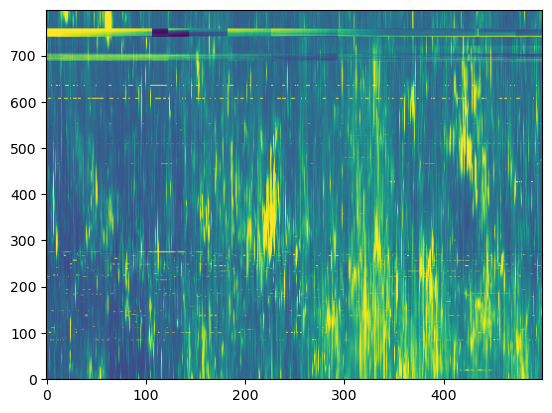

In [41]:
plt.imshow(dset[0, :, :].T, origin='lower', aspect='auto')
dset.shape

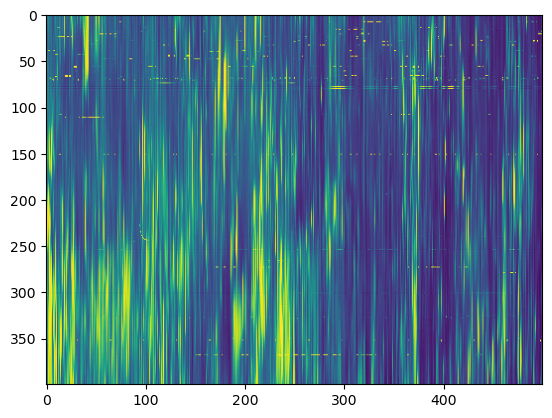

In [42]:
dataset = dset[:, :, 200:600]
plt.imshow(dataset[30, :, :].T, aspect='auto')

In [35]:
# Normalize the data from mattia code

def sigmoid(x, s, c):
    return 1 / (1 + np.exp(-(x - c) / s))

def resize_np(image, new_shape):
    """Resize a 2D numpy array to new_shape using scipy.ndimage.zoom."""
    zoom_factors = (new_shape[0] / image.shape[0], new_shape[1] / image.shape[1])
    return zoom(image, zoom_factors, order=1)  # order=1: bilinear interpolation

def download_and_normalize(dset):
    imdata = dset[0, :, :].T  # Assuming dset is a numpy array with shape (N, M)

    normalization = np.mean(
        np.sort(imdata, 0)[
            int(imdata.shape[0] * 0.1):int(imdata.shape[0] * 0.3), :
        ], 0
    )
    normalized = imdata / normalization
    vmin, vmax = np.percentile(normalized, (20, 80))
    center = np.mean([vmax, vmin])
    scale = vmax - vmin
    normalized = sigmoid(normalized, scale, center)

    # Resize to (500, 800) using scipy
    resized = resize_np(normalized, (500, 800))
    return resized

(500, 800)

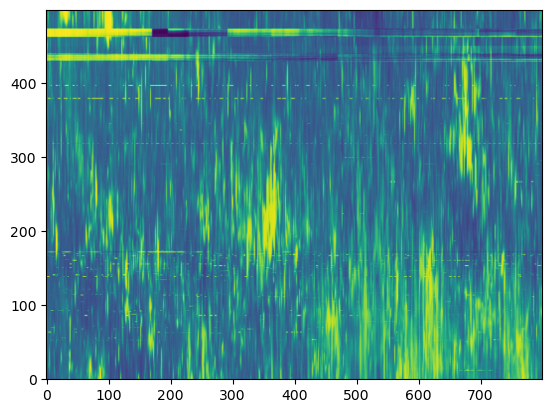

In [36]:
image = download_and_normalize(dset)

plt.imshow(image[:, :], origin='lower', aspect='auto')
image.shape